# YOLO on VisDrone2019 — Inference and Evaluation

---

Our interest with this notebook is to show what happens when applying [**YOLOv11**](https://platform.ultralytics.com/ultralytics/yolo11/yolo11n), which has been pretrained on the [COCO dataset](https://docs.ultralytics.com/datasets/detect/coco/), on the [VisDrone2019-DET](https://docs.ultralytics.com/datasets/detect/visdrone/) validation set with **no fine-tuning**.

### Dataset
- **VisDrone2019-DET**: 548 validation images captured by UAVs over 14 cities in China
- **10 classes**: pedestrian, people, bicycle, car, van, truck, tricycle, awning-tricycle, bus, motor
- **~2.6 million** annotated bounding boxes across the full dataset

### Limitations of this evaluation
1. YOLO was pretrained on COCO (ground-level imagery). VisDrone is aerial → **domain shift** is guaranteed.
2. ~60% of objects in VisDrone are **tiny** (<32×32 px). The base model was not optimized for small-object detection.
3. The classes `pedestrian` and `people` overlap semantically with COCO's `person` — this may artificially inflate those class metrics.

## 0. Install dependencies

In [12]:
# Run only if not already installed
# !pip install ultralytics opencv-python matplotlib numpy

## 1. Imports and configuration

Let's import the necessary dependencies. The one we use for calling the YOLO model and the Visdrone dataset is the `ultralytics` one. The directory for saving all the outputs of our notebook will be called `outputs`.

In [13]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import cv2
from ultralytics import YOLO

# Datos de Ciencia color palette
PALETTE = {
    "bg":     "#0D1117",
    "orange": "#E85D24",
    "amber":  "#F5A623",
    "yellow": "#FCDE5A",
    "white":  "#FFFFFF",
    "gray":   "#334155",
}

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)
print("Configuration ready ✓")

Configuration ready ✓


The `MODEL_NAME` and `DATA_CONFIG` will be used for calling defining the model and the dataset. `IMGSZ` refers to the target image size that we are expecting to use for training. 

In [14]:
MODEL_NAME  = "yolo11n.pt"    # nano variant: lightweight and fast. Switch to yolo11s/m for higher mAP
DATA_CONFIG = "VisDrone.yaml" # Ultralytics downloads VisDrone automatically on first run
IMGSZ = 640 # Target image size for training

The correspondence of the numeric labels with the classes will be present in the `VisDrone.yaml` once it is downloaded. However, since this notebook intends to show everything as directly as possible, we will hardcode them along with the RGB colors for each of the classes.

In [15]:
VISDRONE_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]

# Per-class BGR colors for bounding box visualization
CLASS_COLORS_BGR = [
    (36,  93, 232), (35, 165, 245), (36, 232, 166), (36, 165,  36),
    (245, 166, 35), (232,  93,  36), (166,  35, 245), (245,  35, 166),
    (36,  36, 232), (232, 232,  36),
]

## 2. Load pretrained model

YOLOv11n pretrained on **COCO** (80 classes, ground-level imagery).
Ultralytics downloads the weights automatically if not found locally.

**Why the nano variant for this baseline?**  
A baseline should be simple, reproducible, and require minimal compute. Using the smallest model variant makes the zero-shot result easy to replicate on any machine, and sets a honest lower bound. This will be the base model for comparing the results of models we will develop later.

In [16]:
model = YOLO(MODEL_NAME)
print(f"Model loaded: {MODEL_NAME}")
print(f"COCO classes available: {len(model.names)}")
print(f"Total parameters: {sum(p.numel() for p in model.model.parameters()):,}")

Model loaded: yolo11n.pt
COCO classes available: 80
Total parameters: 2,624,080


## 3. Evaluation on VisDrone-val

### Metrics

Object detection differs from classification: rather than assigning a single label to an image, the model must simultaneously **localize** each object with a bounding box and **classify** it. This means evaluation requires measuring both how well the boxes are placed and how correctly the classes are assigned.

The standard localization metric is **Intersection over Union (IoU)**, defined for a predicted box $b$ and a ground-truth box $g$ as:

$$\text{IoU}(b, g) = \frac{|b \cap g|}{|b \cup g|}$$

IoU ranges from 0 (no overlap) to 1 (perfect overlap). A prediction is considered to have found an object only if its IoU with a ground-truth box exceeds a fixed threshold.

**Precision** and **Recall** are then defined from:
- **TP** (True Positive): predicted box whose IoU with an unmatched ground-truth box $\geq$ `IOU_THRESH`
- **FP** (False Positive): predicted box with no matching ground-truth box
- **FN** (False Negative): ground-truth box that was not matched by any prediction

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

**Average Precision (AP)** summarizes performance independently of any single threshold choice. Sweeping $\tau$ from 1 down to 0 generates a sequence of $(P(\tau), R(\tau))$ pairs — as $\tau$ decreases, recall monotonically increases because more boxes survive the filter. This traces a curve in precision-recall space, and AP is the area under that curve with respect to recall:

$$AP = \int_0^1 P(r)\, dr \approx \sum_{k=1}^{n} (r_k - r_{k-1}) \cdot p_k$$

The variable of integration is recall $r$, not $\tau$ — sweeping $\tau$ is the mechanism that generates the curve, and the integral is the area under it.

**mAP** averages AP across all classes. The COCO benchmark defines two variants:
- **mAP@50**: IoU threshold fixed at 0.50 — lenient localization requirement
- **mAP@50-95**: averaged over IoU $\in \{0.50, 0.55, \ldots, 0.95\}$ — the strict standard COCO metric

$$\text{mAP@50-95} = \frac{1}{10} \sum_{t \in \{0.50, 0.55,\ldots, 0.95\}} \text{mAP}(t)$$

### Model thresholds

Two thresholds control inference:

- `CONF_THRESH` $(\tau)$: filters predicted boxes *before* comparison with ground truth. Only boxes with confidence score $c \geq \tau$ survive to be evaluated as TP or FP.
- `IOU_THRESH`: used in **Non-Maximum Suppression (NMS)** to remove duplicate boxes for the same object — predicted boxes with IoU greater than this threshold relative to a higher-confidence box are suppressed. It is also used as the matching threshold when assigning TP/FP.

It is worth being explicit about when `CONF_THRESH` actually matters, because it plays a different role depending on context:

| Context | Role of `CONF_THRESH` |
|---|---|
| `model.val()` → AP | Ignored for AP. Ultralytics internally sweeps the full curve from $\tau = 0.001$ to $1$ regardless of what you pass. Your value only affects the scalar P and R printed below, which are computed at a single $\tau$. |
| `model.predict()` → deployment | Operational filter. The only threshold that matters — it determines which boxes the model proposes in a real-time system or API. |

This distinction matters beyond this notebook: in the MLOps video of this series, when we deploy this model as an API, tuning `CONF_THRESH` becomes one of the primary operational levers. At that point it has nothing to do with AP — it is a production decision about the precision-recall tradeoff you are willing to accept in deployment.

As you raise `CONF_THRESH`, precision tends to increase — only high-confidence predictions survive, so fewer false positives pass through. Recall drops because true objects whose confidence falls below $\tau$ are missed, becoming false negatives. Lowering `CONF_THRESH` has the opposite effect.

Precision and recall are therefore not fixed properties of the model — they are functions of $\tau$. It is also worth noting that `CONF_THRESH` is not a probability threshold in the strict sense: YOLO's confidence score $c$ is not a calibrated probability. It is the product of two sigmoid outputs from the network head:

$$c = \hat{p}(\text{object}) \times \hat{p}(\text{class} \mid \text{object})$$

so $c = 0.8$ does not mean $P(\text{box is correct}) = 0.8$. In practice, YOLO tends to produce lower $c$ values on out-of-distribution data — which is part of what we will observe on VisDrone, where domain shift causes confidence scores to collapse even for objects the model would detect correctly on COCO.

Because AP integrates over all values of $\tau$, it is the right metric for comparing two models. Comparing precision or recall at a single `CONF_THRESH` is misleading if one model is simply more or less aggressive by default. When `model.val()` reports AP, it sweeps the full curve internally — your threshold only affects the visual predictions and the raw printed counts below.

In [17]:
CONF_THRESH = 0.25            # confidence threshold for predictions
IOU_THRESH  = 0.45            # IoU threshold for NMS

Since we are interested on checking the performance of the model on a validation dataset that contains the ground-truth labels, we will use the `model.val` method. The method for just making predictions without ground-truth comparison is `model.predict` and will be used in further sections.

In [18]:
results = model.val(
    data=DATA_CONFIG,
    imgsz=IMGSZ,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    verbose=False,
    plots=False,
)

print(f"\nmAP@50     : {results.box.map50:.4f}")
print(f"mAP@50-95  : {results.box.map:.4f}")
print(f"Precision  : {results.box.mp:.4f}")
print(f"Recall     : {results.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.11.0+cu126 CUDA:0 (NVIDIA RTX A4500, 20171MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 5.7±2.1 MB/s, size: 177.6 KB)
val: Scanning /scratchsan/observatorio/juagudeloo/YoutubeChannel/Astro2business-ComputerVisionSeries/YOLO/notebooks/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 67.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 17.8it/s 2.0s0.0s
                   all        548      38759     0.0724     0.0128    0.00585     0.0031
Speed: 0.3ms preprocess, 1.3ms inference, 0.0ms loss, 0.4ms postprocess per image

mAP@50     : 0.0059
mAP@50-95  : 0.0031
Precision  : 0.0724
Recall     : 0.0128


## 4. Per-class metrics

Based on the resulting predictions on the Validation dataset, let's see how well each of the classes perform based on the AP score.

In [19]:
ap50_per_class = results.box.ap50
class_indices  = results.box.ap_class_index

per_class = {}
for idx, ap50 in zip(class_indices, ap50_per_class):
    cls_name = VISDRONE_CLASSES[idx] if idx < len(VISDRONE_CLASSES) else f"cls_{idx}"
    per_class[cls_name] = float(ap50)

print(f"{'Class':<20} {'AP@50':>8}")
print("-" * 30)
for cls, ap in sorted(per_class.items(), key=lambda x: -x[1]):
    bar = "█" * int(ap * 25)
    print(f"{cls:<20} {ap:>8.4f}  {bar}")

Class                   AP@50
------------------------------
pedestrian             0.0541  █
truck                  0.0028  
awning-tricycle        0.0015  
car                    0.0001  
bicycle                0.0000  
people                 0.0000  
van                    0.0000  
tricycle               0.0000  
bus                    0.0000  
motor                  0.0000  


As we can see, pedestrian tends to be predicted better. This makes sense thinking about **domain-shift**. Since drone images have a different inclination than ground-based images, the aspect ratio of most elements change, being the most affected ones the objects where its shape highly changes such as two vehicle transport that also loses characteristics such as, for example, its wheels. In the case of pedestrian, even if when inclined, human bodies tend to look like blobs, characteristics such as arms and legs are kept making it easier for the model to classify them. 

**NOTE:** It is worth mentioning that, even though pedestrians had the best AP, it still scores pretty low. **Domain-shift** keeps being the key concept here.

## 5. Metrics visualization

/tmp/ipykernel_3272726/400894956.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


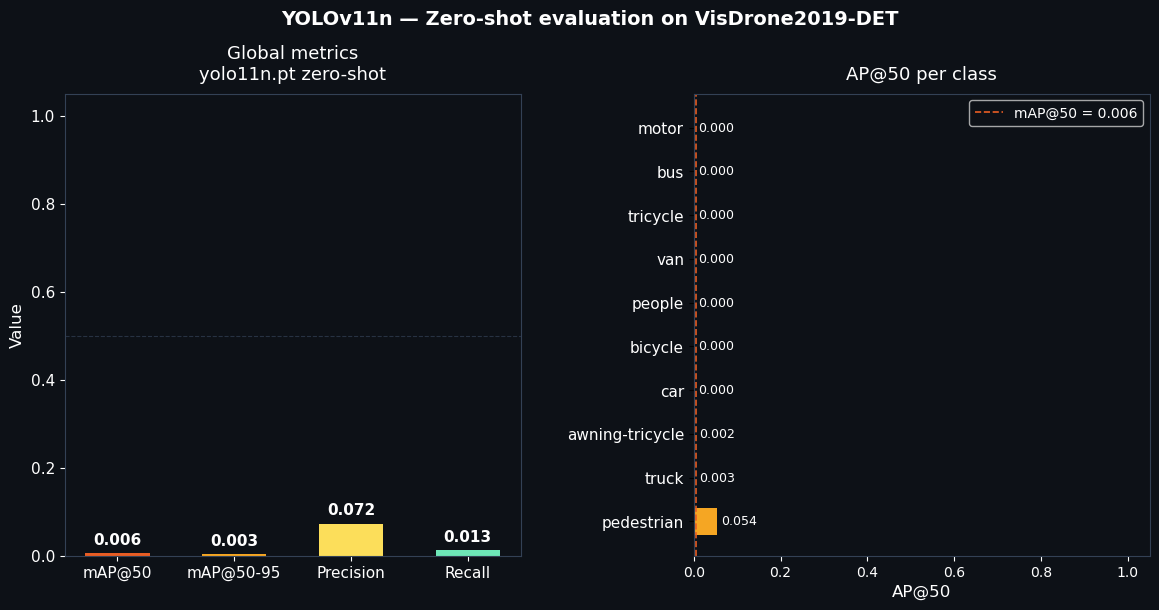

Figure saved to outputs/metrics_summary.png


In [20]:
mAP50   = float(results.box.map50)
mAP5095 = float(results.box.map)
prec    = float(results.box.mp)
rec     = float(results.box.mr)

fig = plt.figure(figsize=(14, 6), facecolor=PALETTE["bg"])
gs  = GridSpec(1, 2, figure=fig, wspace=0.38)

# Global metrics
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PALETTE["bg"])
names_g = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
vals_g  = [mAP50, mAP5095, prec, rec]
cols_g  = [PALETTE["orange"], PALETTE["amber"], PALETTE["yellow"], "#6EE7B7"]
bars1 = ax1.bar(names_g, vals_g, color=cols_g, edgecolor="none", width=0.55)
ax1.set_ylim(0, 1.05)
ax1.tick_params(colors=PALETTE["white"], labelsize=11)
ax1.spines[:].set_color(PALETTE["gray"])
ax1.set_ylabel("Value", color=PALETTE["white"], fontsize=12)
ax1.set_title(f"Global metrics\n{MODEL_NAME} zero-shot",
              color=PALETTE["white"], fontsize=13, pad=10)
for bar, val in zip(bars1, vals_g):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", color=PALETTE["white"], fontsize=11, fontweight="bold")
ax1.axhline(0.5, color=PALETTE["gray"], linestyle="--", linewidth=0.8, alpha=0.7)

# Per-class AP
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PALETTE["bg"])
if per_class:
    sorted_pairs = sorted(per_class.items(), key=lambda x: -x[1])
    cls_names, ap_vals = zip(*sorted_pairs)
    y_pos = np.arange(len(cls_names))
    ax2.barh(y_pos, ap_vals, color=PALETTE["amber"], edgecolor="none", height=0.6)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(cls_names, color=PALETTE["white"], fontsize=11)
    ax2.set_xlim(0, 1.05)
    ax2.tick_params(axis="x", colors=PALETTE["white"])
    ax2.spines[:].set_color(PALETTE["gray"])
    ax2.set_xlabel("AP@50", color=PALETTE["white"], fontsize=12)
    ax2.set_title("AP@50 per class", color=PALETTE["white"], fontsize=13, pad=10)
    ax2.axvline(mAP50, color=PALETTE["orange"], linestyle="--",
                linewidth=1.2, label=f"mAP@50 = {mAP50:.3f}")
    ax2.legend(facecolor=PALETTE["bg"], labelcolor=PALETTE["white"], fontsize=10)
    for i, val in enumerate(ap_vals):
        ax2.text(val + 0.01, i, f"{val:.3f}", va="center",
                 color=PALETTE["white"], fontsize=9)

fig.suptitle("YOLOv11n — Zero-shot evaluation on VisDrone2019-DET",
             color=PALETTE["white"], fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(out_dir / "metrics_summary.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Figure saved to outputs/metrics_summary.png")

## 6. Visualize predictions on real images

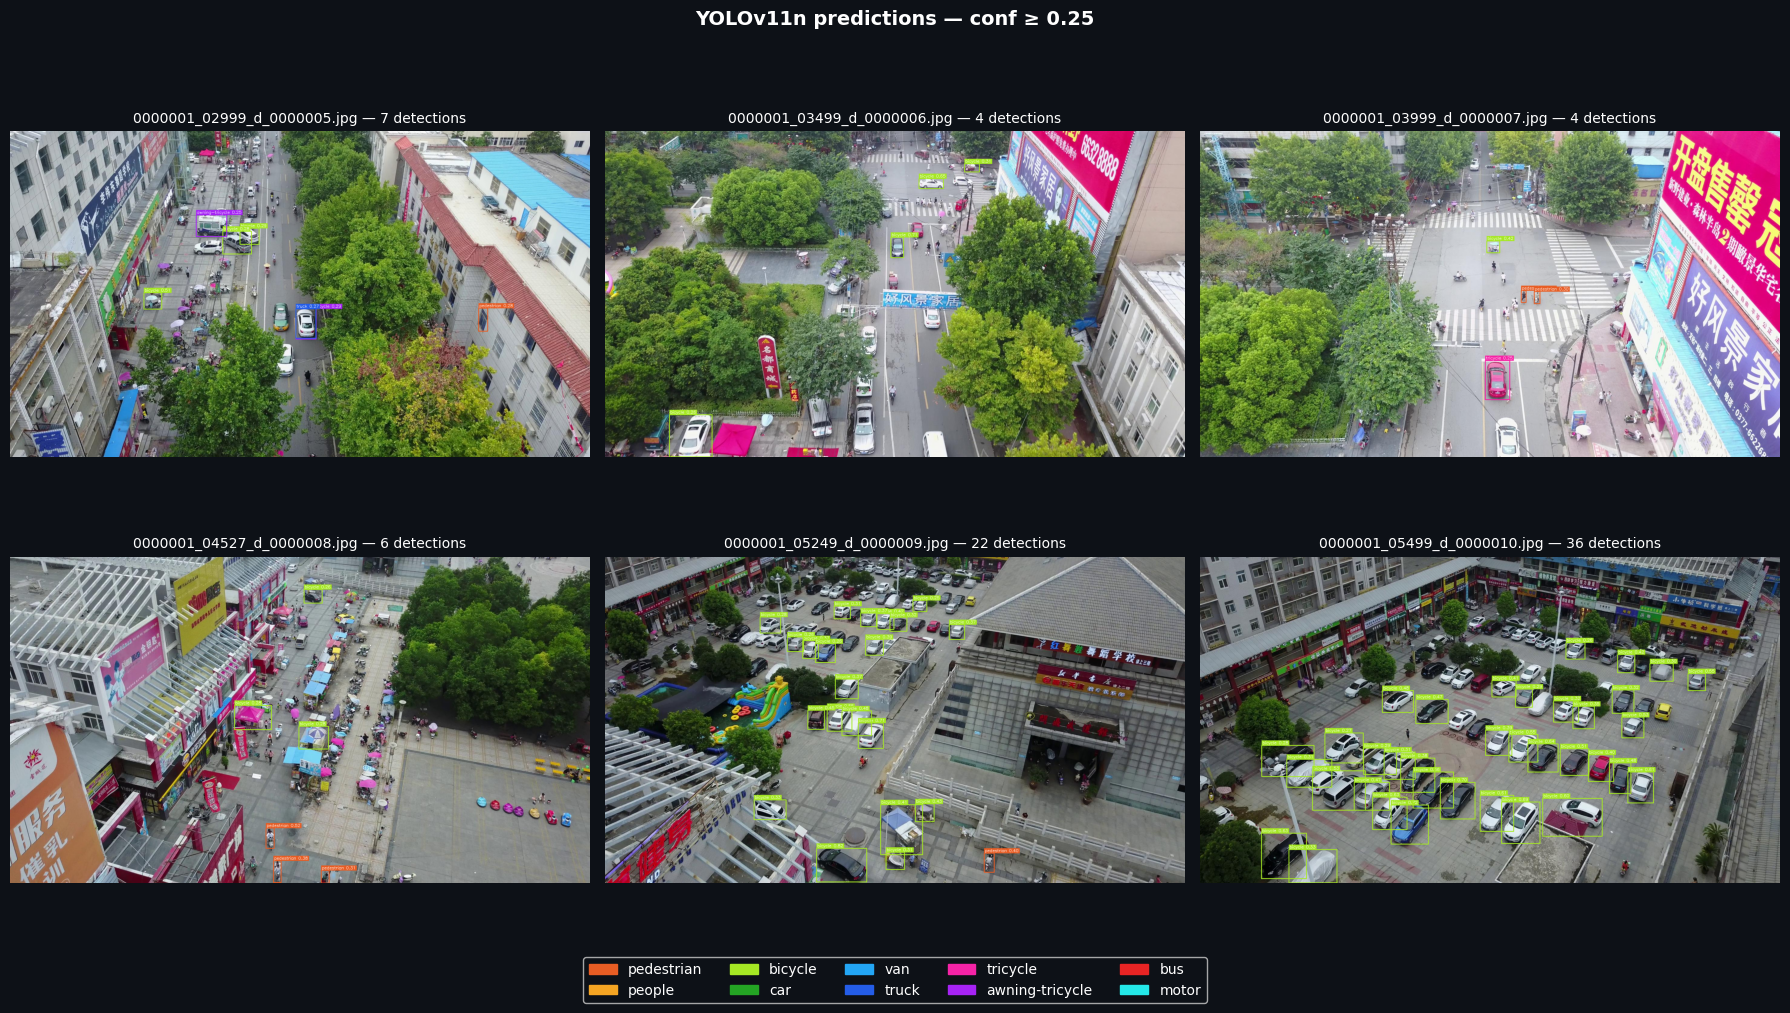

Grid saved to outputs/predictions_grid.png


In [ ]:
import yaml
from ultralytics.utils import DATASETS_DIR


N_VIZ = 6               # number of images to visualize
val_dir = Path(DATASETS_DIR) / "VisDrone" / "images" / "val"
img_paths = sorted(val_dir.glob("*.jpg"))[:N_VIZ]

results_list = model.predict(
    source=[str(p) for p in img_paths],
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    imgsz=IMGSZ,
    verbose=False,
)

cols = 3
rows = (N_VIZ + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5),
                          facecolor=PALETTE["bg"])
axes = axes.flatten()
for ax in axes:
    ax.axis("off")
    ax.set_facecolor(PALETTE["bg"])

for i, (res, img_path) in enumerate(zip(results_list, img_paths)):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if res.boxes is not None and len(res.boxes):
        for box in res.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            color  = CLASS_COLORS_BGR[cls_id % len(CLASS_COLORS_BGR)][::-1]
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            label = f"{VISDRONE_CLASSES[cls_id] if cls_id < len(VISDRONE_CLASSES) else cls_id} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            cv2.rectangle(img_rgb, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
            cv2.putText(img_rgb, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

    n_det = len(res.boxes) if res.boxes is not None else 0
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{img_path.name} — {n_det} detections",
                      color=PALETTE["white"], fontsize=10)

patches = [
    mpatches.Patch(color=[c/255 for c in CLASS_COLORS_BGR[j][::-1]],
                   label=VISDRONE_CLASSES[j])
    for j in range(len(VISDRONE_CLASSES))
]
fig.legend(handles=patches, loc="lower center", ncol=5,
           facecolor=PALETTE["bg"], labelcolor=PALETTE["white"],
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"YOLOv11n predictions — conf ≥ {CONF_THRESH}",
             color=PALETTE["white"], fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(out_dir / "predictions_grid.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Grid saved to outputs/predictions_grid.png")

## 7. Summary: Why are these metrics low?

### Domain shift

COCO was collected primarily with ground-level cameras. VisDrone is **aerial**. The visual appearance of objects differs fundamentally:
- Top-down (nadir) view vs. horizontal perspective
- Objects are much smaller in pixel area
- Different aspect ratios (cars seen from above are nearly square)

This is exactly the **domain shift** phenomenon observed in production when a model trained on lab data is deployed on real-world data from a different distribution.

### The small-object problem

YOLO processes images at $640 \times 640$ resolution. An object of $8 \times 8$ px occupies:

$$\frac{8 \times 8}{640 \times 640} = \frac{64}{409600} \approx 0.016\%$$

of the total image area. With so few pixels, the backbone has very limited information to extract discriminative features from.

### Class overlap

The classes `pedestrian` and `people` both map loosely to COCO's `person`. This means the model may produce correct-looking detections on those classes for the wrong reasons — not because it learned the aerial viewpoint, but because `person` features from COCO partially transfer. This is a form of **label leakage** that inflates those specific AP values and makes the baseline look better than it truly is on the aerial domain.

### What comes next → Next video: Fine-tuning

Fine-tuning YOLO on VisDrone-train should significantly improve these metrics, especially for small classes like `motor` and `bicycle` where zero-shot performance is weakest.